- 'Unnamed: 0' - индекс
- 'property_id' - ...
- 'location_id' - ...
- 'page_url' - адрес с которого взята информация
- 'property_type' - квартира, дом или пентхаус
- 'price' - цена (целевая переменная)
- 'location' - название квартала города
- 'city' - 5 различных городов
- 'province_name' - ...
- 'latitude' - координта
- 'longitude' - координата
- 'baths' - количество ванных комнат
- 'purpose' - для продажи или в аренду (модель строилась только на данных для продажи)
- 'bedrooms' - количество спален
- 'date_added' - дата публиковки объявления
- 'agency' - агенство недвижимости
- 'agent' - агент
- 'Total_Area' - площадь в квадратных футах

In [129]:
import pandas as pd
import numpy as np
import sklearn
import scipy
import seaborn as sns
import matplotlib.pyplot as plt
import catboost
import xgboost
import catboost
import lightgbm
import category_encoders
import re
import nltk

In [130]:
data = pd.read_csv('Entities.csv')

In [131]:
data = data[data['purpose'] == 'For Sale']
data

,Unnamed: 0,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,purpose,bedrooms,date_added,agency,agent,Total_Area
0,0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,For Sale,2,2/4/2019,NaN,NaN,1089.004
1,1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,For Sale,3,5/4/2019,NaN,NaN,15246.056
2,2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,For Sale,5,7/17/2019,NaN,NaN,2178.008
3,3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,For Sale,4,4/5/2019,NaN,NaN,10890.000
4,4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,For Sale,3,7/10/2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,2178.008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168441,168441,17355248,6754,https://www.zameen.com/Property/gulshan_e_maym...,House,26500000,Gadap Town,Karachi,Sindh,25.029909,67.137192,0,For Sale,6,7/18/2019,Al Shahab Enterprises,Shahmir,26136.096
168442,168442,17355249,680,https://www.zameen.com/Property/gadap_town_gul...,House,12500000,Gadap Town,Karachi,Sindh,25.017951,67.136393,0,For Sale,3,7/18/2019,Al Shahab Enterprises,Shahmir,2178.008
168443,168443,17355250,6757,https://www.zameen.com/Property/gulshan_e_maym...,House,27000000,Gadap Town,Karachi,Sindh,25.015384,67.116330,0,For Sale,6,7/18/2019,Al Shahab Enterprises,Shahmir,26136.096
168444,168444,17355251,6752,https://www.zameen.com/Property/gulshan_e_maym...,House,11000000,Gadap Town,Karachi,Sindh,25.013265,67.120818,0,For Sale,3,7/18/2019,Al Shahab Enterprises,Shahmir,21235.578


In [132]:
data.isna().sum()

Unnamed: 0           0
property_id          0
location_id          0
page_url             0
property_type        0
price                0
location             0
city                 0
province_name        0
latitude             0
longitude            0
baths                0
purpose              0
bedrooms             0
date_added           0
agency           31463
agent            31464
Total_Area           0
dtype: int64

In [133]:
data.duplicated().sum()

np.int64(0)

In [134]:
data = data.drop(columns = ['Unnamed: 0', 'page_url', 'property_id', 'location_id', 'purpose'])

In [135]:
date = pd.to_datetime(data['date_added'])
data = data.drop(columns = ['date_added'])

data['year'] = date.dt.year
data['month'] = date.dt.month
data['day'] = date.dt.day

In [136]:
data = data.fillna('other')

In [137]:
data.dtypes

property_type     object
price              int64
location          object
city              object
province_name     object
latitude         float64
longitude        float64
baths              int64
bedrooms           int64
agency            object
agent             object
Total_Area       float64
year               int32
month              int32
day                int32
dtype: object

In [138]:
def metrics(y, y_m, price):
    print(f"RMSE: {np.sqrt(sklearn.metrics.mean_squared_error(y, y_m)) / 1000000}")
    print()
    print(f"MAE: {sklearn.metrics.mean_absolute_error(y, y_m) / 1000000}") 
    print()
    print(f"MAPE: {sklearn.metrics.mean_absolute_percentage_error(y, y_m)}")
    print()
    print(f"R²: {sklearn.metrics.r2_score(y, y_m)}") 
    print()
    print()
    print(f'Среднее значение цены: {price.mean() / 1000000}')
    print(f'Медиана цены: {price.median() / 1000000}')
    print(f'Стандартное отклонение цены: {price.std() / 1000000}')

In [139]:
def get_numerical_statistics(values : pd.Series):
    print(f'Среднее значение: {values.mean()}')
    print(f'Медиана: {values.median()}')
    print(f'Минимальное значение: {values.min()}')
    print(f'Максимальное значение: {values.max()}')
    print(f'Стандартное отклонение: {values.std()}')
    print(f'Межквартильный размах: {scipy.stats.iqr(values)}')
    print(f'Процентили: P10 - {np.percentile(values, 10)} P20 - {np.percentile(values, 20)}, P50 - {np.percentile(values, 50)}, P75 - {np.percentile(values, 75)}, P95 - {np.percentile(values, 95)}, P99 - {np.percentile(values, 99)}')

<Axes: >

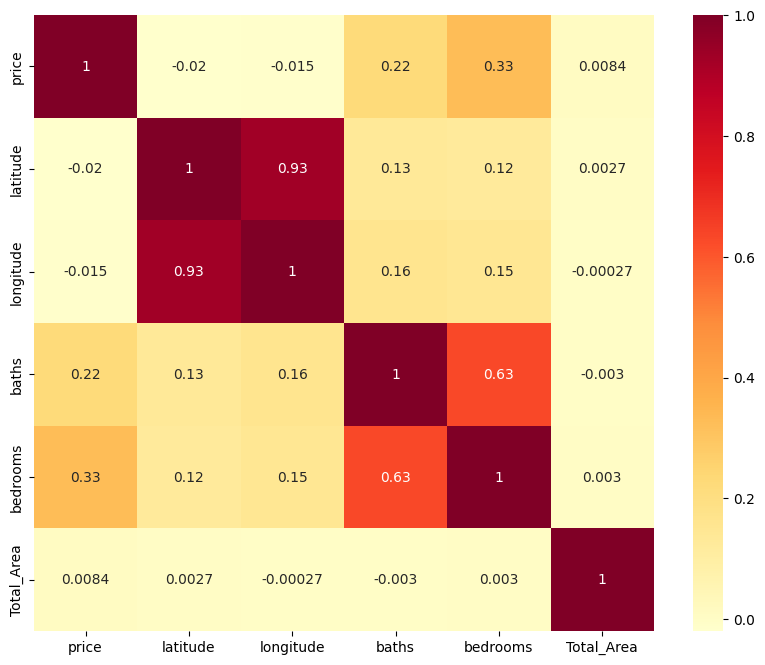

In [140]:

fig, ax = plt.subplots(1, 1, figsize = (10, 8))

sns.heatmap(pd.concat([data.select_dtypes([np.int16, np.int64, np.float64])], axis = 1).corr(method = 'pearson'), 
            cmap = 'YlOrRd', annot = True, ax = ax)

<Axes: xlabel='Total_Area'>

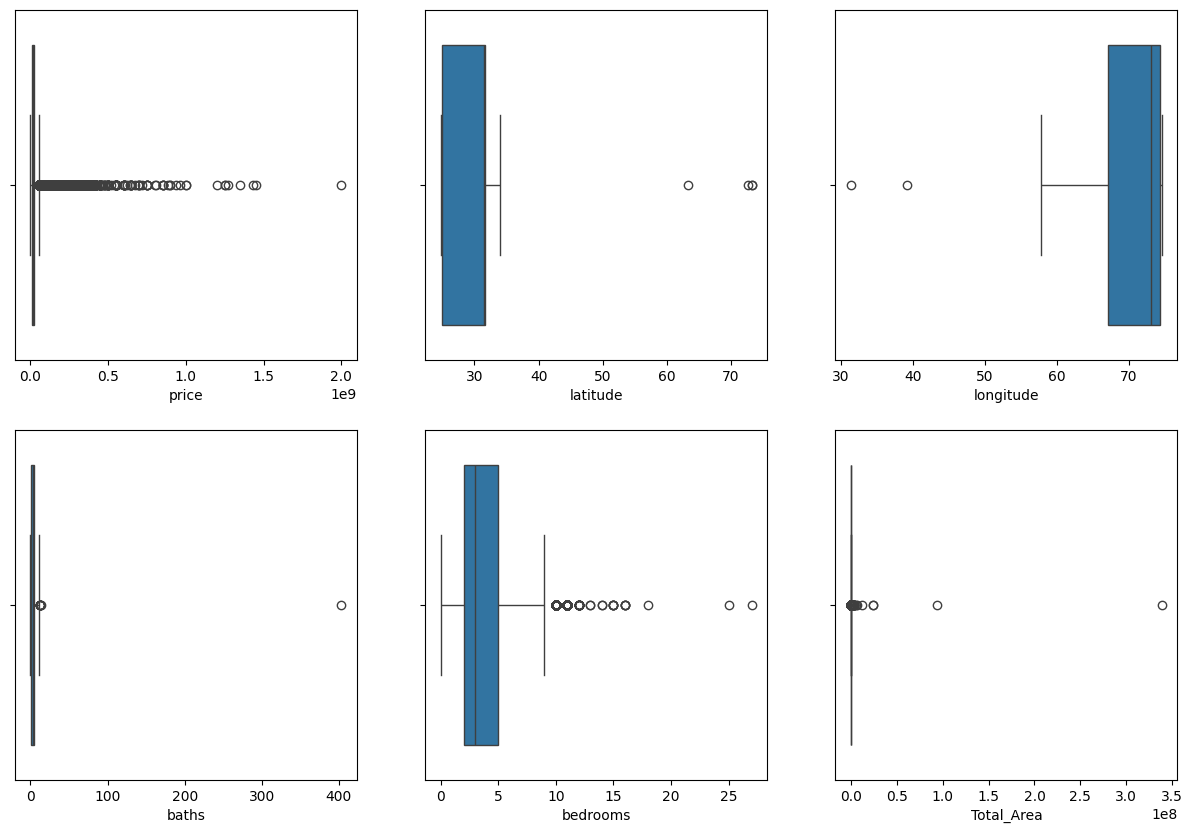

In [141]:
fig, ax = plt.subplots(2, 3, figsize = (15, 10))

sns.boxplot(x = 'price', data = data, ax = ax[0][0])
sns.boxplot(x = 'latitude', data = data, ax = ax[0][1])
sns.boxplot(x = 'longitude', data = data, ax = ax[0][2])
sns.boxplot(x = 'baths', data = data, ax = ax[1][0])
sns.boxplot(x = 'bedrooms', data = data, ax = ax[1][1])
sns.boxplot(x = 'Total_Area', data = data, ax = ax[1][2])

In [142]:
get_numerical_statistics(data['price'] / 1000000)

Среднее значение: 24.76512835012225
Медиана: 13.5
Минимальное значение: 0.0
Максимальное значение: 2000.0
Стандартное отклонение: 39.5975363800628
Межквартильный размах: 18.6
Процентили: P10 - 4.5 P20 - 6.5, P50 - 13.5, P75 - 26.0, P95 - 80.0, P99 - 183.64999999997963


In [143]:
get_numerical_statistics(data['latitude'])

Среднее значение: 29.434610650283364
Медиана: 31.429589
Минимальное значение: 24.749425
Максимальное значение: 73.184088
Стандартное отклонение: 3.6794156614219875
Межквартильный размах: 6.638801000000001
Процентили: P10 - 24.879857 P20 - 24.926606, P50 - 31.429589, P75 - 31.585176, P95 - 33.67164, P99 - 33.713488


In [144]:
get_numerical_statistics(data['longitude'])

Среднее значение: 71.20058085991553
Медиана: 73.07416
Минимальное значение: 31.389173
Максимальное значение: 74.564727
Стандартное отклонение: 3.281108087337946
Межквартильный размах: 7.127387000000013
Процентили: P10 - 67.059474 P20 - 67.081294, P50 - 73.07416, P75 - 74.256549, P95 - 74.432459, P99 - 74.470553


In [145]:
get_numerical_statistics(data['baths'])

Среднее значение: 3.085947536364013
Медиана: 3.0
Минимальное значение: 0
Максимальное значение: 403
Стандартное отклонение: 2.560651751334982
Межквартильный размах: 4.0
Процентили: P10 - 0.0 P20 - 0.0, P50 - 3.0, P75 - 5.0, P95 - 7.0, P99 - 8.0


In [146]:
get_numerical_statistics(data['bedrooms'])

Среднее значение: 3.4013841117235093
Медиана: 3.0
Минимальное значение: 0
Максимальное значение: 27
Стандартное отклонение: 1.9283594580688999
Межквартильный размах: 3.0
Процентили: P10 - 0.0 P20 - 2.0, P50 - 3.0, P75 - 5.0, P95 - 6.0, P99 - 9.0


In [147]:
get_numerical_statistics(data['Total_Area'])

Среднее значение: 14328.432631345571
Медиана: 3811.514
Минимальное значение: 0.0
Максимальное значение: 338798790.0
Стандартное отклонение: 1018422.8836039904
Межквартильный размах: 9801.036
Процентили: P10 - 1089.004 P20 - 1361.255, P50 - 3811.514, P75 - 11434.542, P95 - 31308.865, P99 - 81675.0


**Обучение без feature engineering**

In [148]:
price_no_fe = data['price']
data_no_fe = data.drop(columns = ['price'])

x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(data_no_fe, price_no_fe, test_size = 0.1, shuffle = True)

encoder = category_encoders.TargetEncoder(cols=x_train.select_dtypes([object]).columns, smoothing=10)
x_train = encoder.fit_transform(x_train, y_train)
x_test = encoder.transform(x_test)

model_test1 = xgboost.XGBRegressor(random_state = 1)
model_test1.fit(x_train, y_train)

cat_boost_test1_predicted = model_test1.predict(x_test)

metrics(y_test, cat_boost_test1_predicted, price_no_fe)

RMSE: 20.410231137409884

MAE: 5.6941965

MAPE: 1.169050790430507e+19

R²: 0.7411818504333496


Среднее значение цены: 24.76512835012225
Медиана цены: 13.5
Стандартное отклонение цены: 39.5975363800628


**feature engineering**

In [149]:

for column in data.select_dtypes([np.int32, np.int64]).columns:
    if np.max(data[column]) < 32000:
        data[column] = data[column].astype(np.int16)

data = data[(data['price'] >= np.percentile(data['price'], 1)) & (data['price'] <= np.percentile(data['price'], 99))].copy()

data = data[data['baths'] <= np.percentile(data['baths'], 99)].copy()
data = data[data['bedrooms'] <= np.percentile(data['bedrooms'], 99)].copy()
data = data[(data['Total_Area'] >= np.percentile(data['Total_Area'], 1)) & (data['Total_Area'] <= np.percentile(data['Total_Area'], 99))].copy()

data = data[data['baths'] != 0].copy()
data = data[data['bedrooms'] != 0].copy()

data['bath_per_bedroom'] = data['baths'] / (data['bedrooms'] + 1)
data['area_per_bedroom'] = data['Total_Area'] / (data['bedrooms'] + 1)
data['bed_bath_ratio'] = data['bedrooms'] / (data['baths'] + 1)

data['bedrooms_squared'] = data['bedrooms'] ** 2
data['rooms_interaction'] = data['baths'] * data['bedrooms']
data['area_per_room'] = data['Total_Area'] / (data['bedrooms'] + 1)

data['avg_rooms'] = (data['baths'] + data['bedrooms']) / 2
data['area_bedroom_interaction'] = data['Total_Area'] * data['bedrooms']
data['area_bath_interaction'] = data['Total_Area'] * data['baths']

data['bed_bath_product'] = data['bedrooms'] * data['baths']
data['area_bath_ratio'] = data['Total_Area'] / (data['baths'] + 1)

data['week_of_year'] = date.dt.isocalendar().week
data['is_weekend'] = (date.dt.dayofweek >= 5).astype(int)
data['days_until_end_of_month'] = date.dt.days_in_month - date.dt.day
data['quarter'] = date.dt.quarter
data['is_month_start'] = (date.dt.day <= 7).astype(int)
data['is_month_end'] = (date.dt.day >= date.dt.days_in_month - 7).astype(int)

data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)
data['day_sin'] = np.sin(2 * np.pi * data['day'] / 31)
data['day_cos'] = np.cos(2 * np.pi * data['day'] / 31)

data['lat_m_long'] = data['latitude'] * data['longitude']
data['lat_d_long'] = data['latitude'] / data['longitude']
data['long_d_lat'] = data['longitude'] / data['latitude']

for column in ['latitude', 'longitude', 'Total_Area', 'area_per_room']:
    data['log_' + column] = np.float32(np.log(data[column]))
    data['squared_' + column] = data[column] ** 2
    data['sqrt_' + column] = np.sqrt(data[column])
    
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()

price = data['price']
data = data.drop(columns = ['price'])

x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(data, price, test_size = 0.1, shuffle = True)

train_data = pd.concat([x_train, y_train], axis=1)

for col in x_train.select_dtypes([object]).columns:
    freq_map = x_train[col].value_counts(normalize=True).to_dict()
    x_train[f'{col}_freq'] = x_train[col].map(freq_map)
    x_test[f'{col}_freq'] = x_test[col].map(freq_map).fillna(0)

encoder = category_encoders.TargetEncoder(cols = x_train.select_dtypes([object]).columns, smoothing=10)
x_train = encoder.fit_transform(x_train, y_train)
x_test = encoder.transform(x_test)

get_numerical_statistics(price / 1000000)

Среднее значение: 21.584245023952498
Медиана: 13.8
Минимальное значение: 1.8
Максимальное значение: 182.5
Стандартное отклонение: 23.735123860025993
Межквартильный размах: 17.5
Процентили: P10 - 4.5 P20 - 6.5, P50 - 13.8, P75 - 25.0, P95 - 66.5, P99 - 127.5


**пробное обучение с feature engineering**

In [150]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

model_test2 = xgboost.XGBRegressor(random_state = 1)
model_test2.fit(x_train, y_train_log)

model_test2_predicted_log = model_test2.predict(x_test)
model_test2_predicted = np.expm1(model_test2_predicted_log)

importance = pd.DataFrame({
    'feature': x_train.columns,
    'importance': model_test2.feature_importances_
}).sort_values('importance', ascending=False)

display(importance)

useless_columns = importance[importance['importance'] == 0]['feature'].tolist()

display(useless_columns)

#дроп не влияющиз на результат фичей
x_train = x_train.drop(columns = useless_columns)
x_test = x_test.drop(columns = useless_columns)

metrics(y_test, model_test2_predicted, y_test)

,feature,importance
18,rooms_interaction,0.441619
20,avg_rooms,0.302570
1,location,0.043127
10,Total_Area,0.040140
6,baths,0.023324
9,agent,0.016508
8,agency,0.015744
37,long_d_lat,0.011717
43,sqrt_longitude,0.011554
0,property_type,0.009644


['bedrooms_squared',
 'area_per_room',
 'bed_bath_product',
 'is_month_start',
 'is_month_end',
 'quarter',
 'log_area_per_room',
 'sqrt_Total_Area',
 'squared_Total_Area',
 'log_Total_Area',
 'squared_area_per_room',
 'sqrt_area_per_room',
 'province_name_freq',
 'city_freq']

RMSE: 7.890207791247072

MAE: 3.51624425

MAPE: 0.16871386766433716

R²: 0.8902006149291992


Среднее значение цены: 21.636169796469133
Медиана цены: 14.0
Стандартное отклонение цены: 23.812936415033604


In [151]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

n_samples = int(x_train.shape[0] * 0.3)
indices = np.random.choice(x_train.shape[0], n_samples, replace=False)

x_tune = x_train.iloc[indices]
y_tune = y_train.iloc[indices]

In [154]:

xgboost_for_tuning = xgboost.XGBRegressor(random_state = 1)

param_grid_xgboost = {
    'n_estimators': [2000, 2250, 2500, 2750, 3000],
    'max_depth': [3, 4, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.02, 0.025, 0.03, 0.032, 0.033, 0.035, 0.04, 0.042, 0.045, 0.05, 0.55, 0.6],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 1.0],
    'reg_alpha': [0, 0.1, 0.25, 0.5, 1, 5, 10],
    'reg_lambda': [0, 0.1, 1, 0.15, 2, 0.25, 3, 4, 5, 6, 10],
    'gamma': [0, 0.025, 0.04, 0.05, 0.06, 0.075, 0.1, 0.2, 0.3, 0.5],
    'min_child_weight': [1, 2, 3, 4, 5, 6],
    'tree_method': ['hist'],
}

random_search_xgboost = sklearn.model_selection.RandomizedSearchCV(
    estimator=xgboost_for_tuning,
    param_distributions=param_grid_xgboost,
    n_iter=30,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2,
    random_state=1,
    return_train_score=True
)

random_search_xgboost.fit(x_tune, y_tune)

best_params_xgb = random_search_xgboost.best_params_

display(best_params_xgb)


Fitting 3 folds for each of 30 candidates, totalling 90 fits


{'tree_method': 'hist',
 'subsample': 0.85,
 'reg_lambda': 3,
 'reg_alpha': 1,
 'n_estimators': 2000,
 'min_child_weight': 4,
 'max_depth': 8,
 'learning_rate': 0.025,
 'gamma': 0.075,
 'colsample_bytree': 0.6}

In [155]:
final_model = xgboost.XGBRegressor(
    **best_params_xgb,
    random_state = 1
)

final_model.fit(x_train, y_train_log)
predicted = np.expm1(final_model.predict(x_test))

importance = pd.DataFrame({
    'feature': x_train.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

metrics(y_test, predicted, price)

display(importance)


RMSE: 7.530492658144485

MAE: 3.2395825

MAPE: 0.15457941591739655

R²: 0.8999839425086975


Среднее значение цены: 21.584245023952498
Медиана цены: 13.8
Стандартное отклонение цены: 23.73512386002599


,feature,importance
17,rooms_interaction,0.312681
18,avg_rooms,0.259944
6,baths,0.143634
1,location,0.044481
10,Total_Area,0.035870
9,agent,0.025279
20,area_bath_interaction,0.021082
7,bedrooms,0.018931
19,area_bedroom_interaction,0.015055
8,agency,0.014449


{'tree_method': 'hist',
 'subsample': 0.8,
 'reg_lambda': 0,
 'reg_alpha': 0,
 'n_estimators': 1400,
 'min_child_weight': 3,
 'max_depth': 9,
 'learning_rate': 0.05,
 'gamma': 0.025,
 'colsample_bytree': 0.8} ыксжибуст бэст
